# Física Computacional 2 - Equações Diferenciais Parciais Elípticas

## Equações diferenciais parciais

Equações diferenciais parciais aparecem na descrição de todos os situações físicas onde as quantidades variam no espaço, ou no espaço e no tempo. Isso inclui fenômenos tão diversos quanto difusão, ondas eletromagnéticas, hidrodinâmica e mecânica quântica. Em geral essas equações não podem ser resolvidas analiticamente e portanto métodos numéricos devem ser empregados. Em um tratamento numérico típico, a variável dependente (como a temperatuda ou o potencial elétrico) é descrita por seus valores em uma grade discretizada de pontos das variáveis independentes (como tempo e espaço) e através de uma discretização apropriada, a equação diferencial parcial é transformada em um conjunto de equações de diferenças que pode ser resolvido por métodos iterativos.

As equações diferenciais parciais mais importantes da Física são de segunda ordem e podem ser classificadas em três tipos: parabólicas, elípticas e hiperbólicas. Equações parabólicas envolvem derivada de primeira ordem em uma das variáveis, mas derivadas de segunda ordem nas outras variáveis. Exemplos são a equação de difusão e a equação de Schrodinger dependente doi tempo, que são de primeira ordem no tempo, mas de segunda ordem no espaço. Equações elípticas envolvem derivadas de segunda ordem em cada uma das variáveis independentes, cada derivada tendo o mesmo sinal quando agrupadas em um lado da equação. Essa classe inclui a equação de Poisson para o potencial eletrostático e a equação de Schrodinger independente do tempo. Finalmente, as equações hiperbólicas envolvem derivadas de segunda ordem de sinais opostos, como na equação de onda descrevendo as vibrações de uma corda esticada. Nessa parte da disciplina, discutiremos alguns métodos para resolver equações elípticas.   

## 1. Potencial Elétrico e Campos: Equação de Laplace

Em regiões do espaço que não contém qualquer carga magnética, o potencial elétrico $V(x,y,z)$ obedece a equação de Laplace,

$$
\frac{\partial^2V}{\partial x^2}+\frac{\partial^2V}{\partial y^2}+\frac{\partial^2V}{\partial z^2}=0.\;\;\;\;\;\; (1)
$$
Para ser resolvida, é necessário definir condições de contorno apropriadas. Podendo ser, por exemplo, o valor de $V$ especificado em uma superfície no espaço $x-y-z$ (condição de Dirichlet), ou das derivadas normais de $V$, ou seja, do campo elétrico, em uma dada superfície (condição de von Neumann). De qualquer modo, o problema é encontrar a função $V(x,y,z)$ que satisfaz a equação de Laplace e ao mesmo tempo as condições de contorno. A abordagem que utilizaremos é o método da relaxação, apropriado para lidar com EDP's elípticas.

Como sempre, começamos definindo uma grade no espaço $x-y-z$. Pontos no espaço serão especificados por inteiros $i$, $j$ e $k$, com $x=i\Delta x$, $y=j\Delta y$, $z=k\Delta z$. Desejamos determinar $V(i,j,k)\equiv V(i\Delta x,j\Delta y,k\Delta z)$ em todos os pontos da grade. O primeiro passo é reescrever a equação (1) em termos de diferenças finitas. Por exemplo, a derivada primeira no ponto $(i,j,k)$ pode ser escrita como (fórmula de três pontos),

$$
\frac{\partial V}{\partial x}\approx\frac{V(i+1,j,k)-V(i-1,j,k)}{2\Delta x}.
$$
Essa derivada também poderia ser escrita como,
$$
\frac{\partial V}{\partial x}\approx\frac{V(i+1,j,k)-V(i,j,k)}{\Delta x},
$$
ou ainda como,
$$
\frac{\partial V}{\partial x}\approx\frac{V(i,j,k)-V(i-1,j,k)}{\Delta x}.
$$
As duas fórmulas anteriores podem ser pensadas como as derivadas calculadas nos pontos $i\pm \frac{1}{2}$ e podem ser utilizadas para obter fórmulas mais simétricas para a segunda derivada:
$$
\frac{\partial^2 V}{\partial x^2}\approx\frac{1}{\Delta x}\left[\frac{\partial V(i+ \frac{1}{2})}{\partial x}-\frac{\partial V(i-\frac{1}{2})}{\partial x}\right].
$$
Substituindo as derivadas primeiras na fórmula anterior obtemos,
$$
\frac{\partial^2 V}{\partial x^2}\approx\frac{1}{\Delta x}\left[\frac{V(i+1,j,k)-V(i,j,k)}{\Delta x}-\frac{V(i,j,k)-V(i-1,j,k)}{\Delta x}\right],
$$
com um pouco de álgebra chegamos em,
$$
\frac{\partial^2 V}{\partial x^2}\approx\frac{V(i+1,j,k)+V(i-1,j,k)-2V(i,j,k)}{\left(\Delta x\right)^2}.
$$
Os resultados para as outras derivadas parciais são semelhantes. Substituindo este resultado na equação de Laplace e resolvendo para $V(i,j,k)$ chegamos em

$$
V(i,j,k)=\frac{1}{6}\left[V(i+1,j,k)+V(i-1,j,k)+V(i,j+1,k)+V(i,j-1,k)+V(i,j,k+1)+V(i,j,k-1)\right],
$$
onde assumimos que os passos ao longo dos eixos $x$, $y$ e $z$ são iguais ($\Delta x=\Delta y=\Delta z$). Essa expressão diz que o valor do potencial em um dado ponto é a média do valor do potencial em todos os pontos imediatamente vizinhos.

Agora buscamos uma estratégia numérica para determinar o potencial, assumindo que $V$ é conhecido apenas nos contornos. A abordagem que faremos é começar com um certo chute inicial para o potencial, $V_0(i,j,k)$. Para obter um chute ainda melhor, usaremos $V_0$ no lado direito da Eq.(2) e obtemos um novo potencial $V_1(i,j,k)$. Repetimos assim o processo, obtento um novo potencial a cada iteração, $V_2(i,j,k)$, etc. O processo iterativo é continuado até atingirmos algum critério de convergência. O ponto principal é que podemos utilizar a Eq.(2) para obter soluções cada vez melhores. Este algoritmo que acabamos de descrever com a equação (2) é conhecido como método de Jacobi e faz parte de uma classe geral de métodos de relaxação.






---
<font color='red'> EXERCÍCIO 1 </font>


Como primeiro exercício, vamos considerar um problema em 2 dimensões. Neste caso, o potencial é dado por:
$$
V(i,j)=\frac{1}{4}\left[V(i+1,j)+V(i-1,j)+V(i,j+1)+V(i,j-1)\right].
$$
Além disso, precisamos definir condições de contorno que estão diretamente conectadas com o problema físico de interesse. Assim, iremos considerar duas placas metálicas com o pontencial fixos, conforme figura abaixo.


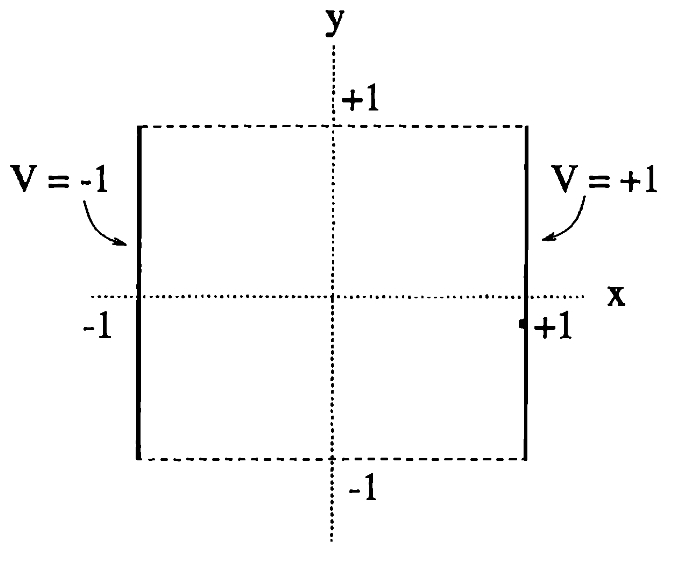

O método numérico de Jacobi se baseia na solução iterativa da equação para o potencial, ou seja,

$$V_n(i,j)=\frac{1}{4}\left[V_{n-1}(i+1,j)+V_{n-1}(i-1,j)+V_{n-1}(i,j+1)+V_{n-1}(i,j-1)\right].$$

onde $V_n(i,j)$ é a solução nova obtida do "chute" anterior $V_{n-1}(i,j)$. É importante lembrar que as condições de contorno são sempre fixas e que somente o potencial em regiões diferentes das condições de contorno deve ser atualizado. O método de Jacobi consiste na solução iterativa da equação acima até que a condição $∑_{i,j}|V_n(i,j)-V_{n-1}(i,j)|<\mathcal{N}ϵ$, onde $\mathcal{N}$ é o número total de pontos. Para o problema das placas paralelas, as condições de contorno são: $V(x=\pm 1,y)=\pm 1$. Além disso, vamos assumir que o potencial em $V(x,y=\pm 1)$ varie linearmente. Como chute inicial, assumimos que o potencial seja nulo nas outras regiões internas do sistema. Vamos também considerar o sistema localizado entre $|x|≤1$ e $|y|≤1$. Por fim, assumimos que $Δx=Δy=0.1$ e $ϵ=10^{-5}$


In [ ]:
a=np.array([1])
b=np.array([2])
a=b
b=np.array([4])
print(a)

[2]


[[-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.  ]
 [-1.    0.    0.    0.    0.    0.    0.    0.    1.  ]
 [-1.    0.    0.    0.    0.    0.    0.    0.    1.  ]
 [-1.    0.    0.    0.    0.    0.    0.    0.    1.  ]
 [-1.    0.    0.    0.    0.    0.    0.    0.    1.  ]
 [-1.    0.    0.    0.    0.    0.    0.    0.    1.  ]
 [-1.    0.    0.    0.    0.    0.    0.    0.    1.  ]
 [-1.    0.    0.    0.    0.    0.    0.    0.    1.  ]
 [-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.  ]]
erro= 8.921410868771573e-06
Número de iterações= 64
[[-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.  ]
 [-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.  ]
 [-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.  ]
 [-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.  ]
 [-1.   -0.75 -0.5  -0.25 -0.    0.25  0.5   0.75  1.  ]
 [-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.  ]
 [-1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.  ]
 [-1.   -0.75 -0.5  -0.25  0.    0.

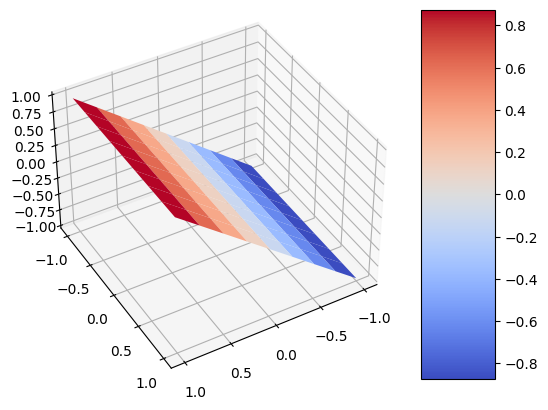

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def atualizaV(N,V):
    Vnew=np.copy(V)
    dV=0.
    for i in range(1,N+1):
      for j in range(1,N+1):
          Vnew[i,j]=(V[i-1,j]+V[i+1,j]+V[i,j-1]+V[i,j+1])/4.
          dV+=np.abs(Vnew[i,j]-V[i,j])
    return (Vnew,dV)

def calcula_laplace(N,V):
    kmax=1000
    error=1.e-5
    k=0
    dV=error
    while dV>=error or k==kmax:
        V,dV=atualizaV(N,V)
        k+=1
    return (V,dV,k)

def inicializaV(N):
    V=np.zeros((N+2,N+2))
    V[:,N+1]=1.
    V[:,0]=-1.
    V[0,:]=np.linspace(-1,1,N+2)
    V[N+1,:]=np.linspace(-1,1,N+2)
    return V

N=7
V=inicializaV(N)
#np.set_printoptions(precision=3,suppress=True)
print(V)

V,dV,Nitera=calcula_laplace(N,V)
print('erro=',dV)
print("Número de iterações=",Nitera)

np.set_printoptions(precision=3,suppress=True)
print(V)

x=np.linspace(-1,1,N+2)
y=np.linspace(-1,1,N+2)
X, Y = np.meshgrid(x, y)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, V, cmap=cm.coolwarm,linewidth=0)
fig.colorbar(surf, shrink=1, aspect=5)
ax.view_init(40, 60)
plt.show()


---
<font color='red'> EXERCÍCIO 2 </font>


Neste exercício, vamos considerar um problema em 2 dimensões com as condições de contorno dadas conforme a figura abaixo.
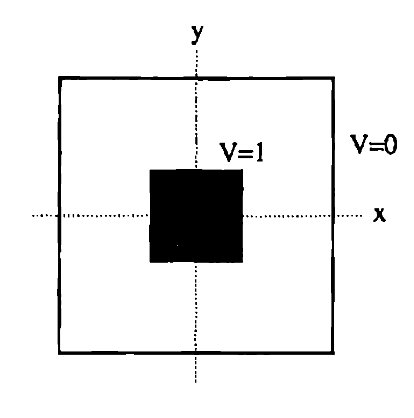

Para este problema, as condições de contorno são: $V(|x|≤0.3,|y|≤0.3)=1$. Além disso, vamos assumir que o potencial nas bordas é nulo $V(\pm 1,\pm 1)=0$. Como chute inicial, assumimos que o potencial seja nulo nas outras regiões internas do sistema. Vamos também considerar o sistema localizado entre $|x|≤1$ e $|y|≤1$. Por fim, assumimos que $Δx=Δy=0.1$ e $ϵ=10^{-5}$.
Faça um gŕafico 3D do potencial elétrico após atingir a convergência.
Você pode usar os comandos conforme exemplificado abaixo:


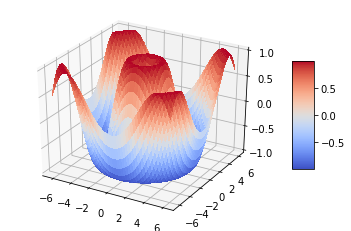

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

N=100
V=np.zeros((N,N))
x=np.zeros(N)
y=np.zeros(N)
h=4*np.pi/N

for i in range(N):
    x[i]=h*i-2*np.pi
    for j in range(N):
        y[j]=h*j-2*np.pi


X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
V = np.sin(R)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(X, Y, V, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(-1.01, 1.01)

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()


## 2. Campo Elétrico

Uma vez obtido o potencial elétrico $V(x,y,z)$ através da solução da equação de Laplace, podemos calcular o campo elétrico
$$
\vec{E}(x,y,z)=-\vec{∇}V(x,y,z)=
-\left[\frac{\partial V}{\partial x}\hat{x}+\frac{\partial V}{\partial y}\hat{y}+\frac{\partial V}{\partial z}\hat{z}\right]\;\;\;\;\;\; (1)
$$
Para encontrar numericamente as derivadas parciais acima, podemos utilizar a seguinte expressão:
$$
E_x=-\frac{\partial V}{\partial x}\approx-\left[\frac{V(i+1,j,k)-V(i-1,j,k)}{2\Delta x}\right].
$$
Usando a aproximação acima, calcule o campo elétrico referente aos exercícios 1 e 2 da aula anterior. Faça o gráfico do campo elétrico usando os comandosdo Python, conforme exemplo abaixo.

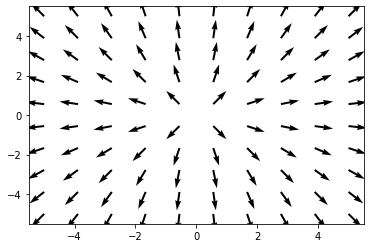

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
x=np.linspace(-5,5,10)
y=np.linspace(-5,5,10)
X,Y = np.meshgrid(x,y)

u = X/np.sqrt(X**2 + Y**2)
v = Y/np.sqrt(X**2 + Y**2)

plt.quiver(X,Y,u,v)
plt.show()


---
<font color='red'> EXERCÍCIO 3 </font>


Neste exercício, vamos considerar o problema de duas placas paralelas finitas em 2 dimensões com as condições de contorno dadas conforme a figura abaixo.


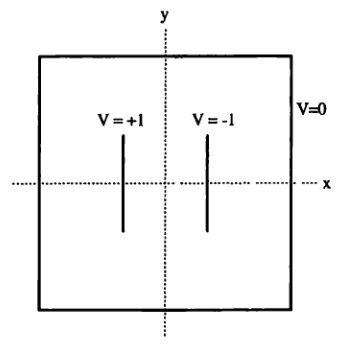

O problema das placas paralelas, possui solução analítica quando as placas são infinitas, a qual é dada por um campo elétrico constante no interior das placas. Neste caso, as placas paralelas são finitas e não há uma solução analítica para esse problema. Além disso, poderemos observar os efeitos de borda, ou seja, como é o campo elétrico nas bordas das placas.
Numericamente, iremos usar o método de Gauss-Siedel, o qual é muito similar ao método de Jacobi, mas possui uma melhora na performance numérica.

O método numérico de Jacobi se baseia na solução iterativa da equação para o potencial, ou seja,

$$V_n(i,j)=\frac{1}{4}\left[V_{n-1}(i+1,j)+V_{n-1}(i-1,j)+V_{n-1}(i,j+1)+V_{n-1}(i,j-1)\right].$$

No entanto, o método de Gauss-Siedel usa a seguinte modificação:

$$V_n(i,j)=\frac{1}{4}\left[V_{n-1}(i+1,j)+\boldsymbol{V_{n}(i-1,j)}+V_{n-1}(i,j+1)+\boldsymbol{V_{n}(i,j-1)}\right],$$
onde $V_n(i,j)$ é a solução nova obtida do "chute" anterior $V_{n-1}(i,j)$. Como os pontos $(i-1,j)$ e $(i,j-1)$ já foram previamente calculados, o método de Gauss-Seidel já os utiliza no cálculo de $V_n(i,j)$.
É importante lembrar que as condições de contorno são sempre fixas e que somente o potencial em regiões diferentes das condições de contorno deve ser atualizado. O método de Gauss-Siedel também consiste na solução iterativa da equação acima até que a condição $∑_{i,j}|V_n(i,j)-V_{n-1}(i,j)|<\mathcal{N}ϵ$, onde $\mathcal{N}$ é o número total de pontos. Para o problema das placas paralelas, as condições de contorno são: $V(x=\pm 0.5,|y|<= 0.5)=\mp 1$. Além disso, vamos assumir que o potencial nas bordas seja nulo, então $V(x=\pm 1,y=\pm 1)=0$. Como chute inicial, assumimos que o potencial seja nulo nas outras regiões internas do sistema. Vamos também considerar o sistema localizado entre $|x|≤1$ e $|y|≤1$. Por fim, assumimos que $Δx=Δy=0.1$ e $ϵ=10^{-5}$ Calcule o campo elétrico referente as placas paralelas e faço o gráfico deste campo vetorial usando os comandos acima. Teste outros valores de $Δx=Δy$ e faça\ o gráfico do campo elétrico.



erro= 9.707634204212875e-06
Número de iterações= 288


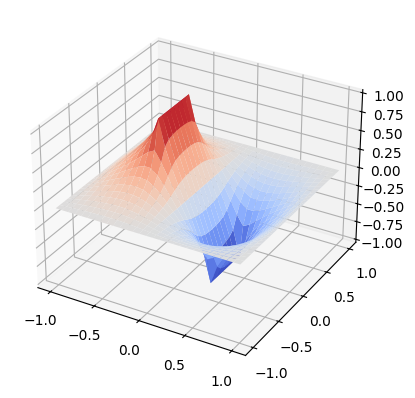

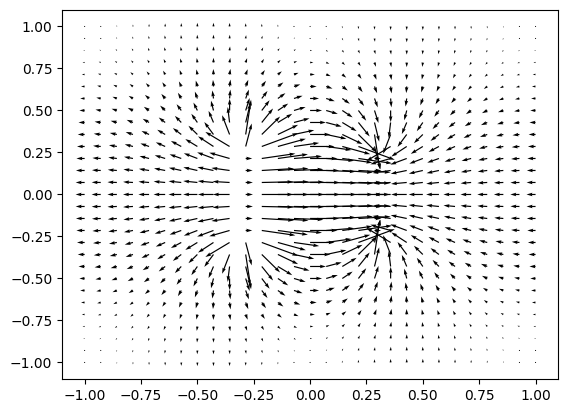

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

#variáveis globais
N=27
jdeltax=int((N+1)/2) # posição da origem em x
ideltay=jdeltax # posição da origem em y
Lx=0.3 # posição da placa negativa no eixo x
ymax=0.3 # tamanho da placa em y 
h=2./(N+1) # espaçamento do grid   
jx=int(Lx/h)
iymax=int(ymax/h)
alpha=1.

def atualizaV(V):
    Vnew=np.zeros((N+2,N+2))
    Vnew = np.copy(V)
    dV=0.
    for i in range(1,N+1):
      for j in range(1,N+1):          
          if j==jdeltax+jx or j==jdeltax-jx:
             if i<=ideltay+iymax and i>=ideltay-iymax:
                 continue               
          Vnew[i,j]=(Vnew[i-1,j]+V[i+1,j]+Vnew[i,j-1]+V[i,j+1])/4.
          dVaux=Vnew[i,j]-V[i,j]
          Vnew[i,j]=alpha*dVaux+V[i,j]
          dV+=np.abs(Vnew[i,j]-V[i,j])
          
                   
    return (Vnew,dV)

def calcula_laplace(V):
    kmax=1000
    error=1.e-5
    k=0
    dV=error
    while dV>=error or k==kmax:
        V,dV=atualizaV(V)
        k+=1
    return (V,dV,k)

def inicializaV():    
    V=np.zeros((N+2,N+2))   
    for iy in range(ideltay-iymax,ideltay+iymax+1):
        V[iy,jdeltax+jx]=-1.
        V[iy,jdeltax-jx]=1.
    return V


# O programa princial começa aqui

V=inicializaV()
V,dV,Nitera=calcula_laplace(V)

print('erro=',dV)
print("Número de iterações=",Nitera)

x=np.zeros(N+2)
y=np.zeros(N+2)

for i in range(N+2):
    y[i]=h*(i-ideltay)
    for j in range(N+2):
        x[j]=h*(j-jdeltax)
       
ax = plt.axes(projection='3d')
X, Y = np.meshgrid(x, y)
ax.plot_surface(X,Y,V,cmap=cm.coolwarm)
#ax.view_init(60, 35)
plt.show()

def CampoE(V,N):
    h=2/(N+1)
    Ex=np.zeros((N+2,N+2))
    Ey=np.zeros((N+2,N+2))
    for i in range(1,N+1):
      for j in range(1,N+1):
          Ey[i,j]=-(V[i+1,j]-V[i-1,j])/(2*h)
          Ex[i,j]=-(V[i,j+1]-V[i,j-1])/(2*h)
    for j in range(N+2):
        Ey[0,j]=-(V[1,j]-V[0,j])/h
        Ey[N+1,j]=-(V[N+1,j]-V[N,j])/h
    for i in range(N+2):
        Ex[i,0]=-(V[i,1]-V[i,0])/h
        Ex[i,N+1]=-(V[i,N+1]-V[i,N])/h
        
    return Ex,Ey


Ex,Ey=CampoE(V,N)
plt.quiver(X,Y,Ex,Ey)
plt.show()